# Clustering Complete Demo: K-Means, Hierarchical, DBSCAN, and Evaluation

CST8506 Advanced Machine Learning - Week 6

Demonstrates all key clustering concepts from the lecture:
1. K-Means basic algorithm and convergence
2. Effect of K and initialization
3. K-Means limitations (non-spherical clusters)
4. Hierarchical clustering with different linkage methods
5. DBSCAN: core, border, noise points
6. K-Means vs DBSCAN comparison
7. Cluster validity: SSE, Silhouette, Elbow Method

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.colors import ListedColormap

## 配置常量 / Configuration Constants

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 输出目录（相对于脚本位置）
# Output directory (relative to script location)
# In notebook, __file__ is not defined, so we use the notebook directory
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    import pathlib
    SCRIPT_DIR = str(pathlib.Path().resolve())
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "week6_clustering_demo_pages")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 可视化配色
# Visualization color scheme
CLUSTER_COLORS = ["#FF4444", "#4444FF", "#44BB44", "#FF8800", "#AA44FF", "#44DDDD"]
FIGSIZE = (10, 6)
DPI = 150

## 演示 1：K-Means 基本算法与收敛 / Demo 1: K-Means Basic Algorithm and Convergence

Demo 1: K-Means Basic Algorithm and Convergence


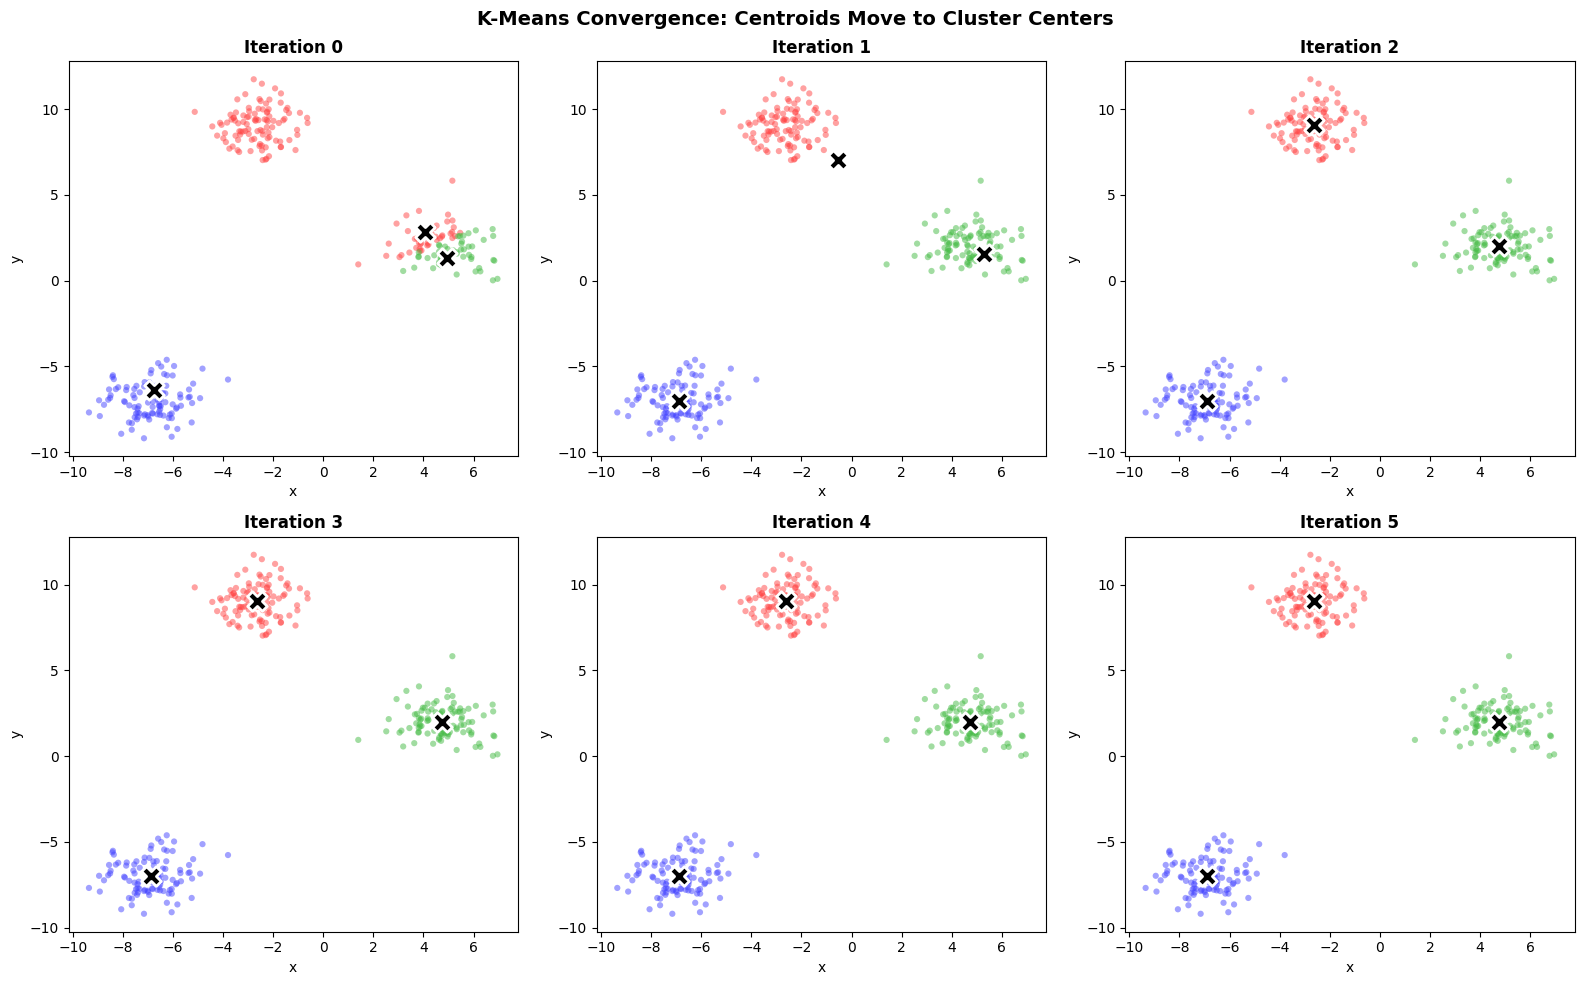

  Final SSE (inertia): 566.86
  Centroids:
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]



In [3]:
print("=" * 60)
print("Demo 1: K-Means Basic Algorithm and Convergence")
print("=" * 60)

# 生成三簇清晰可分的数据
# Generate three clearly separable clusters
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.0,
                               random_state=RANDOM_STATE)

# 手动演示 K-Means 迭代过程
# Manually demonstrate K-Means iteration process
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 随机初始质心
# Random initial centroids
initial_centroids = X_blobs[np.random.choice(len(X_blobs), 3, replace=False)]

for iteration in range(6):
    ax = axes[iteration // 3, iteration % 3]

    if iteration == 0:
        centroids = initial_centroids.copy()
    else:
        # 分配到最近质心
        # Assign to nearest centroid
        distances = np.array([np.linalg.norm(X_blobs - c, axis=1) for c in centroids])
        labels = distances.argmin(axis=0)
        # 重新计算质心
        # Recompute centroids
        centroids = np.array([X_blobs[labels == k].mean(axis=0) for k in range(3)])

    # 当前分配
    # Current assignment
    distances = np.array([np.linalg.norm(X_blobs - c, axis=1) for c in centroids])
    labels = distances.argmin(axis=0)

    for k in range(3):
        mask = labels == k
        ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=CLUSTER_COLORS[k],
                   alpha=0.5, s=20, edgecolors="none")
    ax.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X",
               s=200, edgecolors="white", linewidths=2, zorder=5)
    ax.set_title(f"Iteration {iteration}", fontsize=12, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("K-Means Convergence: Centroids Move to Cluster Centers",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_kmeans_convergence.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()

# 最终结果使用 sklearn
# Final result using sklearn
kmeans_3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans_3.fit(X_blobs)
print(f"  Final SSE (inertia): {kmeans_3.inertia_:.2f}")
print(f"  Centroids:\n{kmeans_3.cluster_centers_}")
print()

## 演示 2：初始化的影响（不同结果） / Demo 2: Effect of Initialization (Different Results)

Demo 2: Effect of Initialization (Different Results)
  seed=0: SSE=5695.07
  seed=7: SSE=566.86
  seed=13: SSE=5693.48
  seed=42: SSE=566.86


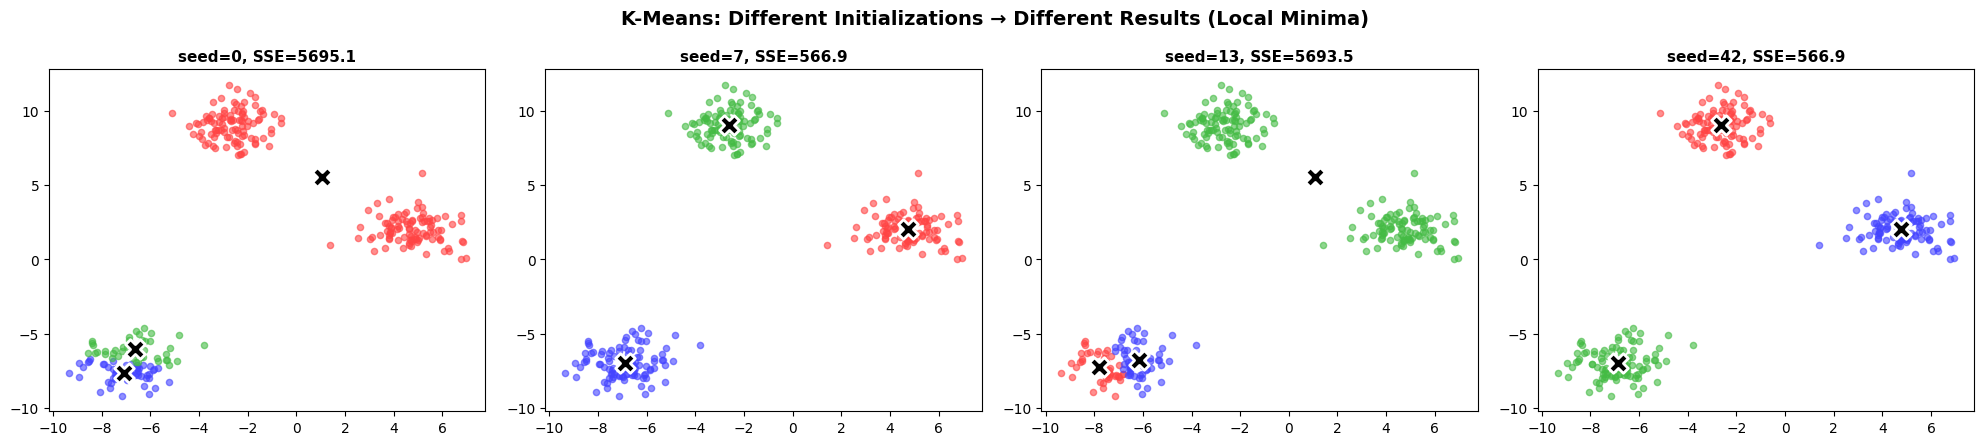

In [4]:
print("=" * 60)
print("Demo 2: Effect of Initialization (Different Results)")
print("=" * 60)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# 使用不同随机种子运行 K-Means，展示结果差异
# Run K-Means with different random seeds to show result variation
seeds = [0, 7, 13, 42]
for ax, seed in zip(axes, seeds):
    km = KMeans(n_clusters=3, random_state=seed, n_init=1, init="random")
    labels = km.fit_predict(X_blobs)
    for k in range(3):
        mask = labels == k
        ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=CLUSTER_COLORS[k],
                   alpha=0.6, s=20)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c="black", marker="X", s=200, edgecolors="white", linewidths=2)
    ax.set_title(f"seed={seed}, SSE={km.inertia_:.1f}", fontsize=11, fontweight="bold")
    print(f"  seed={seed}: SSE={km.inertia_:.2f}")

plt.suptitle("K-Means: Different Initializations → Different Results (Local Minima)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_initialization_effect.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print()

## 演示 3：K-Means 的局限性（非球形簇） / Demo 3: K-Means Limitations (Non-Spherical Clusters)

Demo 3: K-Means Limitations (Non-Spherical Clusters)
  Moons Dataset: K-Means silhouette=0.494
  Moons Dataset: DBSCAN silhouette=0.380, noise=0
  Circles Dataset: K-Means silhouette=0.353
  Circles Dataset: DBSCAN silhouette=0.004, noise=0


C:\Users\40270\AppData\Local\Temp\ipykernel_30348\1428482930.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row, 1].legend(fontsize=8)
C:\Users\40270\AppData\Local\Temp\ipykernel_30348\1428482930.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row, 1].legend(fontsize=8)


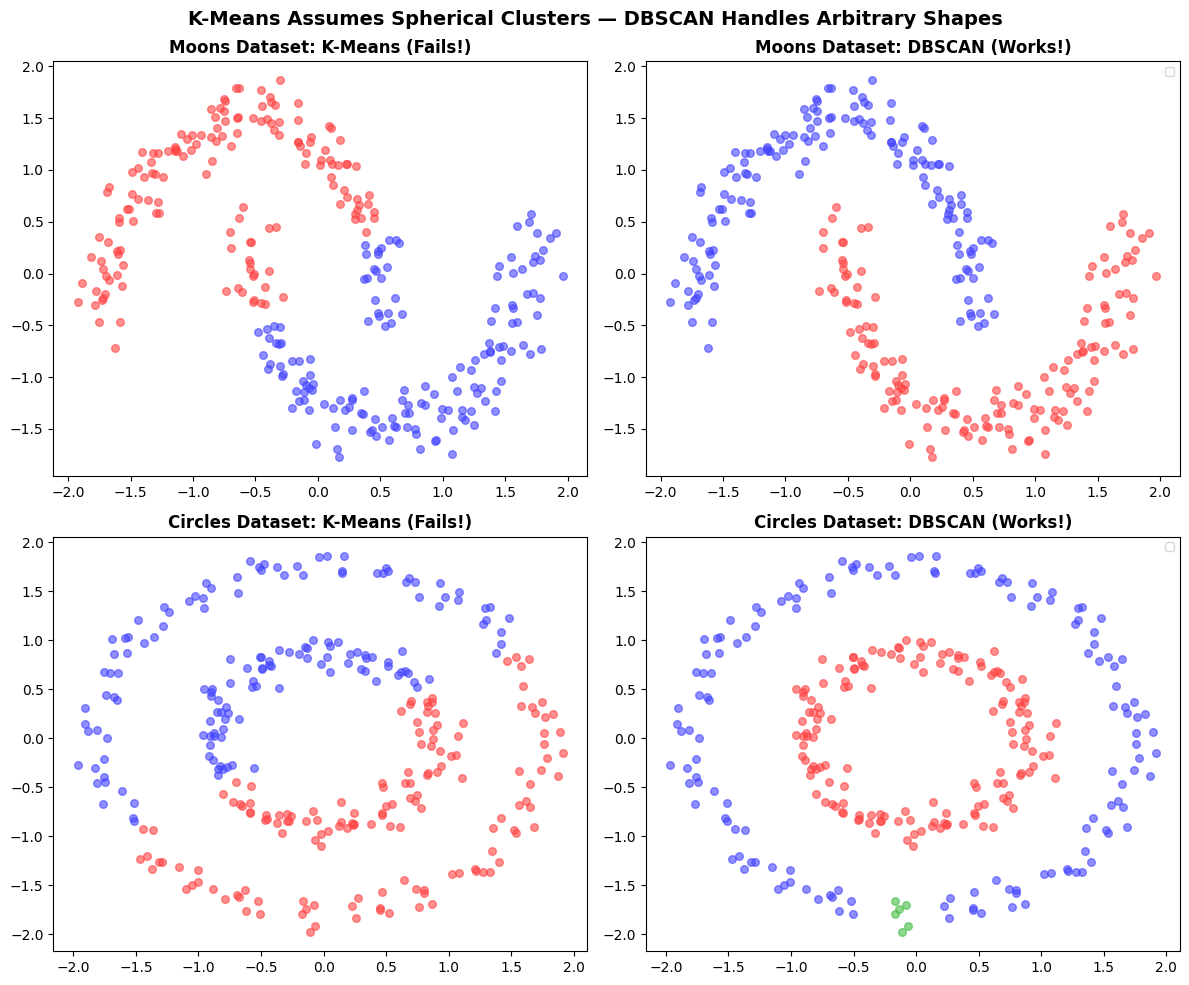

In [5]:
print("=" * 60)
print("Demo 3: K-Means Limitations (Non-Spherical Clusters)")
print("=" * 60)

# 月牙形和环形数据
# Moon-shaped and circle-shaped data
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5,
                                     random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
datasets = [
    (X_moons, "Moons Dataset"),
    (X_circles, "Circles Dataset"),
]

for row, (X, name) in enumerate(datasets):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # K-Means 失败
    # K-Means fails
    km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    for k in range(2):
        mask = labels_km == k
        axes[row, 0].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                             c=CLUSTER_COLORS[k], alpha=0.6, s=30)
    axes[row, 0].set_title(f"{name}: K-Means (Fails!)", fontsize=12, fontweight="bold")

    # DBSCAN 成功
    # DBSCAN succeeds
    db = DBSCAN(eps=0.3, min_samples=5)
    labels_db = db.fit_predict(X_scaled)
    unique_labels = set(labels_db)
    for k in unique_labels:
        mask = labels_db == k
        if k == -1:
            axes[row, 1].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                                 c="gray", marker="x", s=30, alpha=0.5, label="Noise")
        else:
            axes[row, 1].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                                 c=CLUSTER_COLORS[k % len(CLUSTER_COLORS)], alpha=0.6, s=30)
    axes[row, 1].set_title(f"{name}: DBSCAN (Works!)", fontsize=12, fontweight="bold")
    axes[row, 1].legend(fontsize=8)

    print(f"  {name}: K-Means silhouette={silhouette_score(X_scaled, labels_km):.3f}")
    n_noise = (labels_db == -1).sum()
    labels_valid = labels_db[labels_db != -1]
    if len(set(labels_valid)) > 1:
        sil = silhouette_score(X_scaled[labels_db != -1], labels_valid)
        print(f"  {name}: DBSCAN silhouette={sil:.3f}, noise={n_noise}")
    else:
        print(f"  {name}: DBSCAN found 1 cluster + {n_noise} noise points")

plt.suptitle("K-Means Assumes Spherical Clusters — DBSCAN Handles Arbitrary Shapes",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_kmeans_limitations.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print()

## 演示 4：层次聚类与不同链接方法 / Demo 4: Hierarchical Clustering with Different Linkage Methods

Demo 4: Hierarchical Clustering with Different Linkage Methods
  MIN (Single): cluster sizes = [np.int64(10), np.int64(10), np.int64(10)]
  MAX (Complete): cluster sizes = [np.int64(10), np.int64(10), np.int64(10)]
  Group Average: cluster sizes = [np.int64(10), np.int64(10), np.int64(10)]
  Ward's Method: cluster sizes = [np.int64(10), np.int64(10), np.int64(10)]


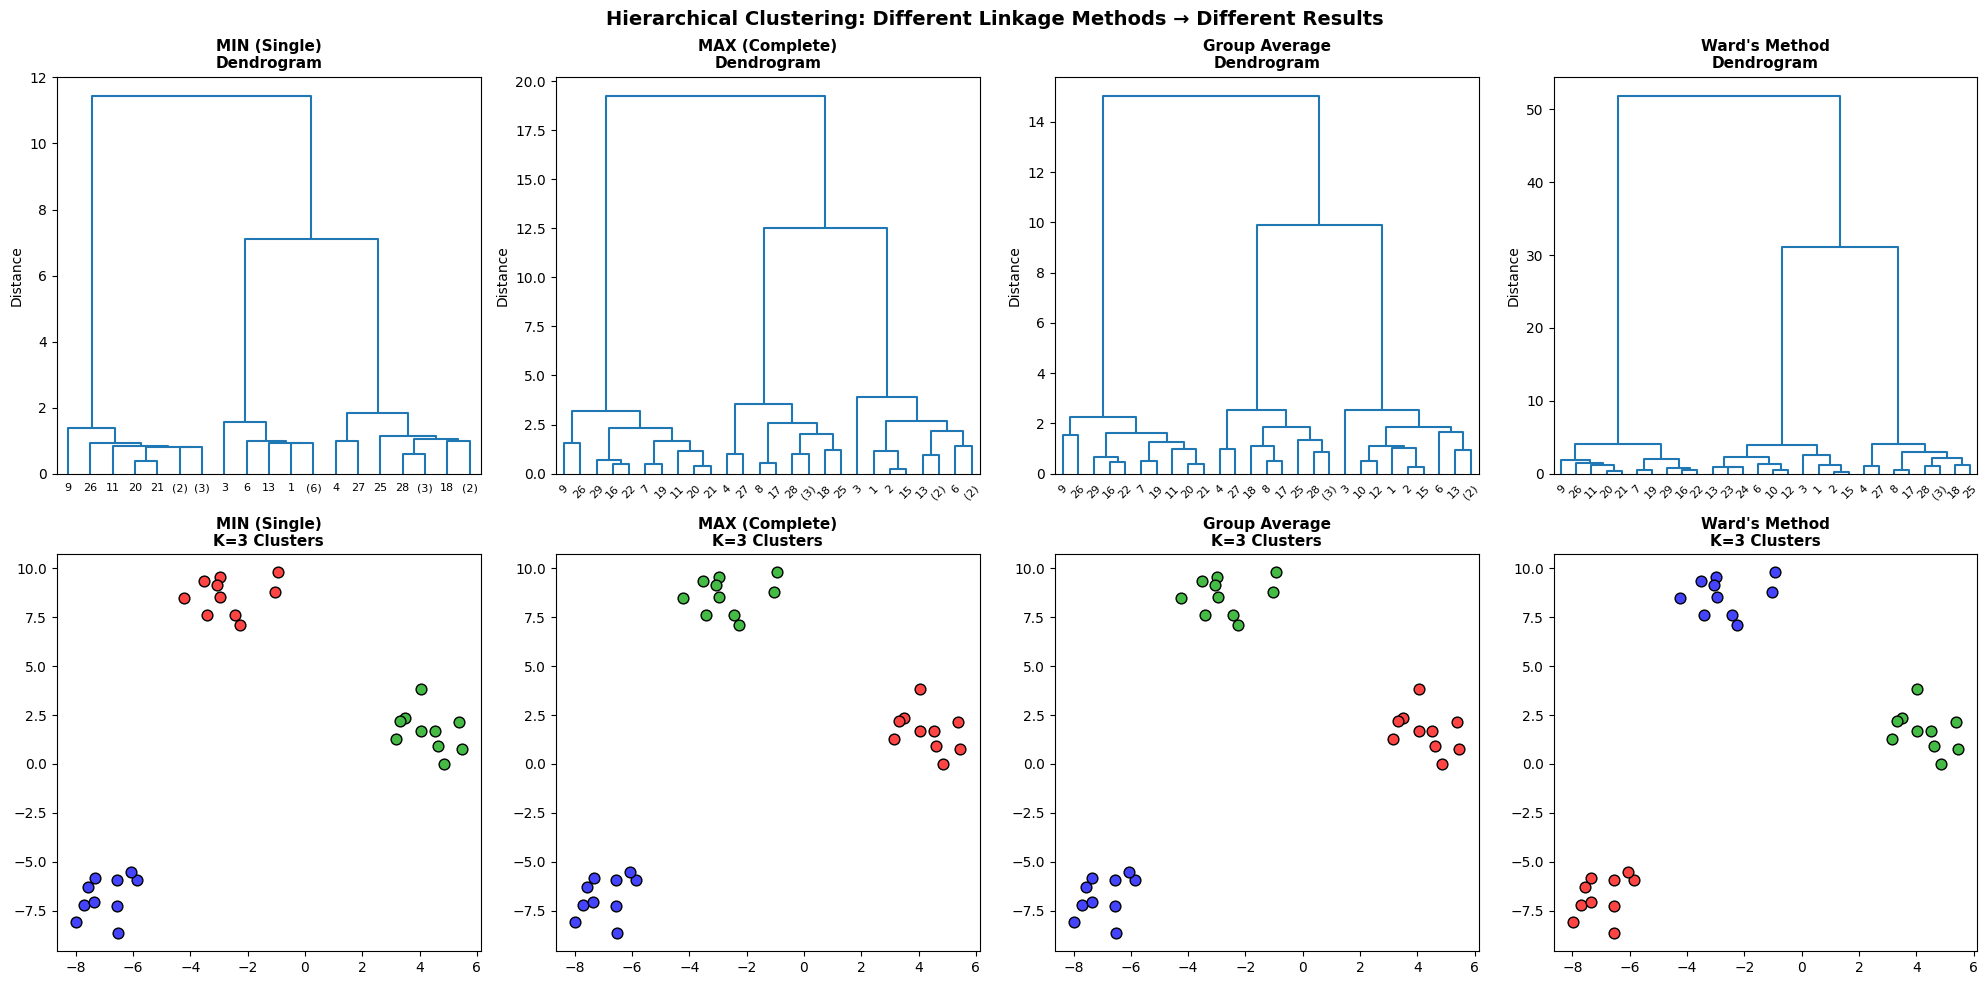

In [6]:
print("=" * 60)
print("Demo 4: Hierarchical Clustering with Different Linkage Methods")
print("=" * 60)

# 使用较少点以便可视化树状图
# Use fewer points for dendrogram visualization
X_small, y_small = make_blobs(n_samples=30, centers=3, cluster_std=1.0,
                               random_state=RANDOM_STATE)

linkage_methods = ["single", "complete", "average", "ward"]
linkage_labels = ["MIN (Single)", "MAX (Complete)", "Group Average", "Ward's Method"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, (method, label) in enumerate(zip(linkage_methods, linkage_labels)):
    # 上排：树状图
    # Top row: dendrogram
    Z = linkage(X_small, method=method)
    dendrogram(Z, ax=axes[0, col], truncate_mode="level", p=5,
               leaf_font_size=8, color_threshold=0)
    axes[0, col].set_title(f"{label}\nDendrogram", fontsize=11, fontweight="bold")
    axes[0, col].set_ylabel("Distance")

    # 下排：聚类结果（K=3）
    # Bottom row: clustering result (K=3)
    hc = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels_hc = hc.fit_predict(X_small)
    for k in range(3):
        mask = labels_hc == k
        axes[1, col].scatter(X_small[mask, 0], X_small[mask, 1],
                             c=CLUSTER_COLORS[k], s=60, edgecolors="k")
    axes[1, col].set_title(f"{label}\nK=3 Clusters", fontsize=11, fontweight="bold")
    print(f"  {label}: cluster sizes = {[sum(labels_hc == k) for k in range(3)]}")

plt.suptitle("Hierarchical Clustering: Different Linkage Methods → Different Results",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_hierarchical_linkage.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print()

## 演示 5：DBSCAN 核心点、边界点、噪声点 / Demo 5: DBSCAN Core, Border, and Noise Points

Demo 5: DBSCAN Core, Border, and Noise Points
  eps=0.3: 4 clusters, 77 noise points, 109 core points
  eps=0.6: 2 clusters, 22 noise points, 177 core points
  eps=1.2: 2 clusters, 8 noise points, 208 core points


C:\Users\40270\AppData\Local\Temp\ipykernel_30348\1991954428.py:44: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(X_noise[border_and_k, 0], X_noise[border_and_k, 1],
C:\Users\40270\AppData\Local\Temp\ipykernel_30348\1991954428.py:44: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(X_noise[border_and_k, 0], X_noise[border_and_k, 1],
C:\Users\40270\AppData\Local\Temp\ipykernel_30348\1991954428.py:44: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(X_noise[border_and_k, 0], X_noise[border_and_k, 1],


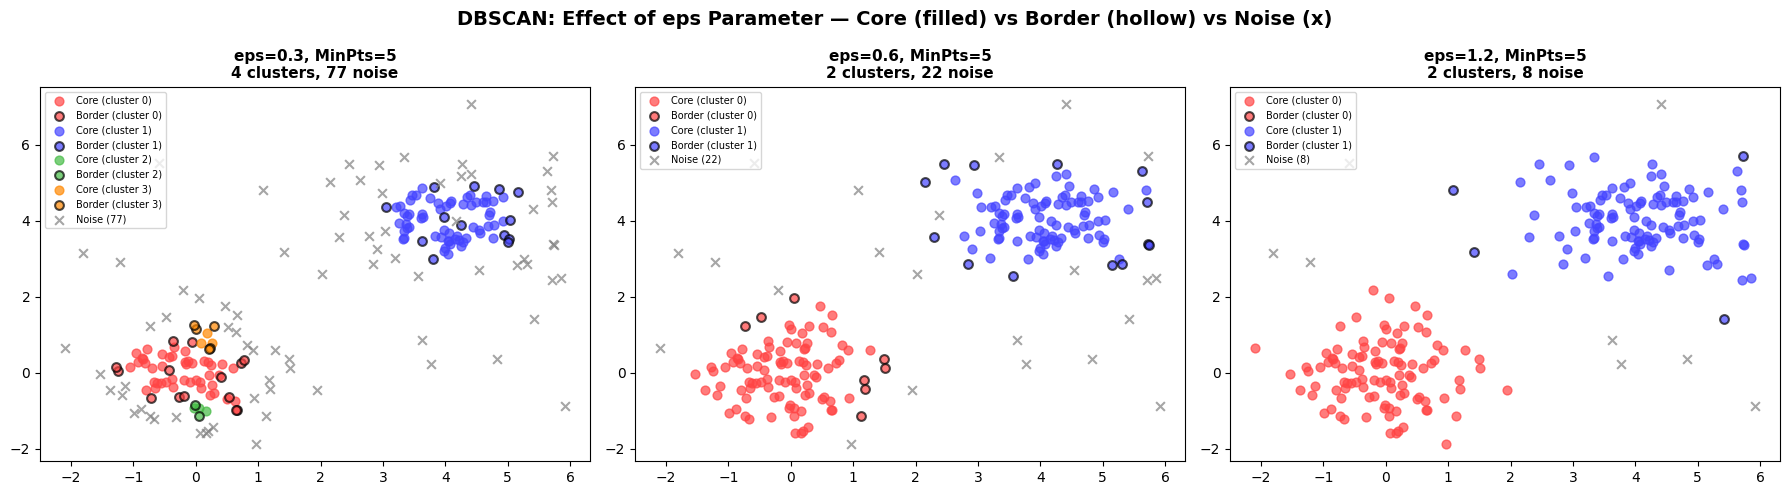

In [7]:
print("=" * 60)
print("Demo 5: DBSCAN Core, Border, and Noise Points")
print("=" * 60)

# 生成带噪声的数据
# Generate data with noise
X_noise = np.vstack([
    make_blobs(n_samples=200, centers=[[0, 0], [4, 4]], cluster_std=0.8,
               random_state=RANDOM_STATE)[0],
    np.random.uniform(-2, 6, size=(20, 2))  # 噪声点 / Noise points
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 不同 eps 参数
# Different eps parameters
eps_values = [0.3, 0.6, 1.2]
for ax, eps_val in zip(axes, eps_values):
    db = DBSCAN(eps=eps_val, min_samples=5)
    labels = db.fit_predict(X_noise)

    # 区分核心点和非核心点
    # Distinguish core points from non-core points
    core_mask = np.zeros(len(X_noise), dtype=bool)
    core_mask[db.core_sample_indices_] = True

    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1})
    n_noise = (labels == -1).sum()

    for k in unique_labels:
        mask = labels == k
        if k == -1:
            ax.scatter(X_noise[mask, 0], X_noise[mask, 1],
                       c="gray", marker="x", s=40, alpha=0.7, label=f"Noise ({mask.sum()})")
        else:
            # 核心点用实心圆，边界点用空心圆
            # Core points = filled, Border points = hollow
            core_and_k = mask & core_mask
            border_and_k = mask & ~core_mask
            ax.scatter(X_noise[core_and_k, 0], X_noise[core_and_k, 1],
                       c=CLUSTER_COLORS[k % len(CLUSTER_COLORS)], s=40, alpha=0.7,
                       label=f"Core (cluster {k})")
            ax.scatter(X_noise[border_and_k, 0], X_noise[border_and_k, 1],
                       c=CLUSTER_COLORS[k % len(CLUSTER_COLORS)], s=40, alpha=0.7,
                       edgecolors="black", linewidths=1.5, facecolors="none",
                       label=f"Border (cluster {k})")

    ax.set_title(f"eps={eps_val}, MinPts=5\n{n_clusters} clusters, {n_noise} noise",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=7, loc="best")
    print(f"  eps={eps_val}: {n_clusters} clusters, {n_noise} noise points, "
          f"{len(db.core_sample_indices_)} core points")

plt.suptitle("DBSCAN: Effect of eps Parameter — Core (filled) vs Border (hollow) vs Noise (x)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_dbscan_points.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print()

## 演示 6：肘部法与轮廓系数选 K / Demo 6: Elbow Method and Silhouette Score for Choosing K

Demo 6: Elbow Method and Silhouette Score for Choosing K


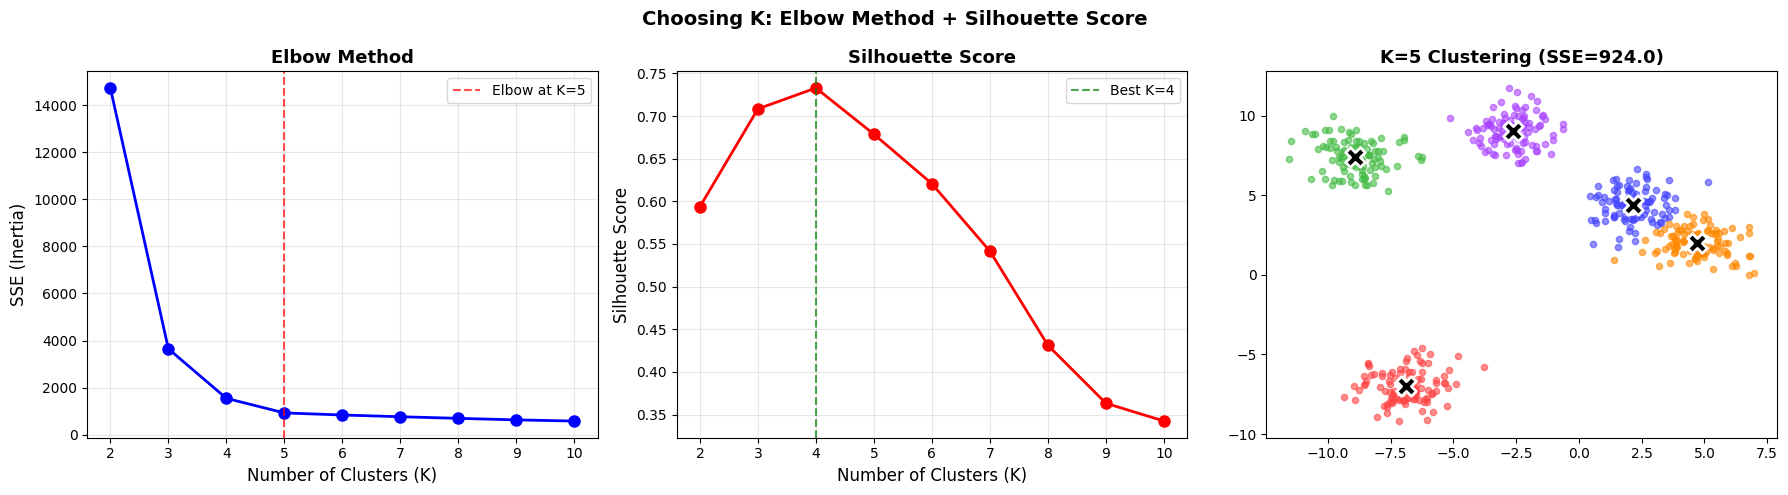

  K=2: SSE=14726.1, Silhouette=0.594
  K=3: SSE=3648.8, Silhouette=0.708
  K=4: SSE=1543.4, Silhouette=0.733 ◀ BEST
  K=5: SSE=924.0, Silhouette=0.679
  K=6: SSE=836.1, Silhouette=0.621
  K=7: SSE=762.0, Silhouette=0.541
  K=8: SSE=693.1, Silhouette=0.431
  K=9: SSE=628.4, Silhouette=0.363
  K=10: SSE=578.1, Silhouette=0.342



In [8]:
print("=" * 60)
print("Demo 6: Elbow Method and Silhouette Score for Choosing K")
print("=" * 60)

# 使用 5 簇数据测试
# Use 5-cluster data for testing
X_5, y_5 = make_blobs(n_samples=500, centers=5, cluster_std=1.0,
                       random_state=RANDOM_STATE)

k_range = range(2, 11)
sse_values = []
sil_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_5)
    sse_values.append(km.inertia_)
    sil_values.append(silhouette_score(X_5, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 肘部法
# Elbow method
axes[0].plot(list(k_range), sse_values, "bo-", linewidth=2, markersize=8)
axes[0].axvline(x=5, color="red", linestyle="--", alpha=0.7, label="Elbow at K=5")
axes[0].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[0].set_ylabel("SSE (Inertia)", fontsize=12)
axes[0].set_title("Elbow Method", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 轮廓系数
# Silhouette score
axes[1].plot(list(k_range), sil_values, "ro-", linewidth=2, markersize=8)
best_k = list(k_range)[np.argmax(sil_values)]
axes[1].axvline(x=best_k, color="green", linestyle="--", alpha=0.7,
                label=f"Best K={best_k}")
axes[1].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Score", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# K=5 最终聚类结果
# K=5 final clustering result
km_final = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
labels_final = km_final.fit_predict(X_5)
for k in range(5):
    mask = labels_final == k
    axes[2].scatter(X_5[mask, 0], X_5[mask, 1], c=CLUSTER_COLORS[k],
                    alpha=0.6, s=20)
axes[2].scatter(km_final.cluster_centers_[:, 0], km_final.cluster_centers_[:, 1],
                c="black", marker="X", s=200, edgecolors="white", linewidths=2)
axes[2].set_title(f"K=5 Clustering (SSE={km_final.inertia_:.1f})",
                  fontsize=13, fontweight="bold")

plt.suptitle("Choosing K: Elbow Method + Silhouette Score",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_choosing_k.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()

for k, (sse, sil) in zip(k_range, zip(sse_values, sil_values)):
    marker = " ◀ BEST" if k == best_k else ""
    print(f"  K={k}: SSE={sse:.1f}, Silhouette={sil:.3f}{marker}")
print()

## 演示 7：四种算法大比较 / Demo 7: All Four Algorithms Side-by-Side

Demo 7: All Four Algorithms Comparison


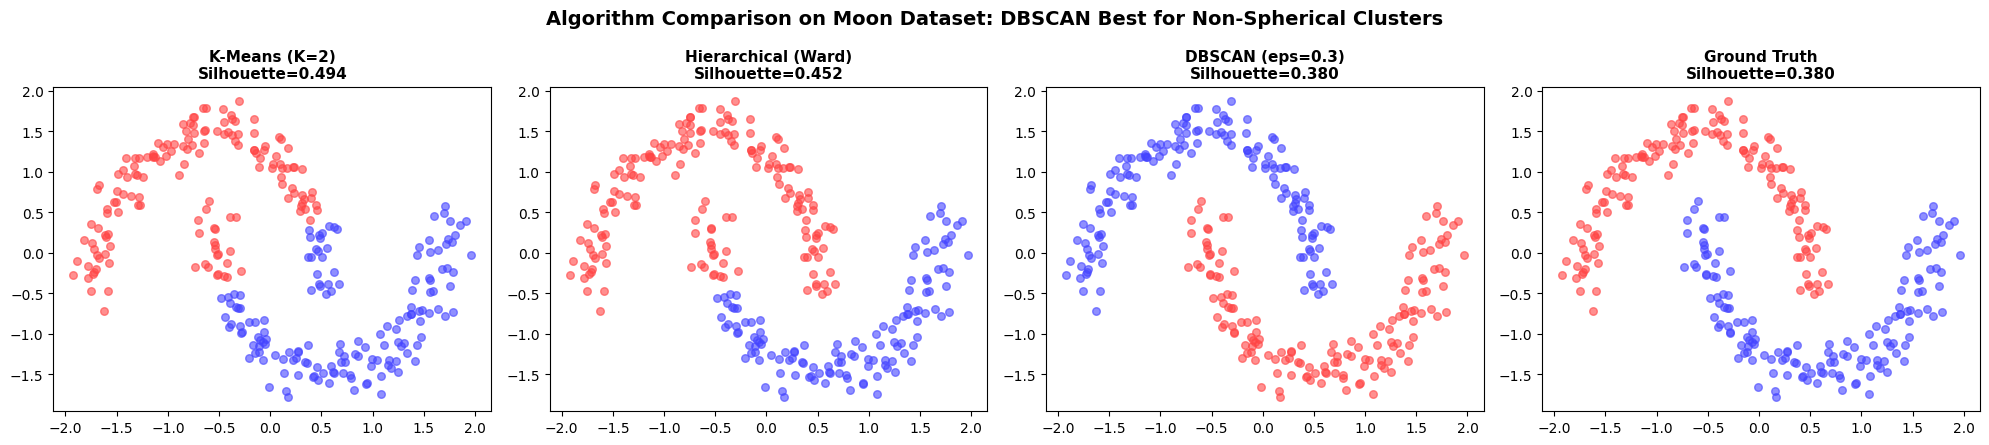

  K-Means:      Silhouette=0.494
  Hierarchical:  Silhouette=0.452
  DBSCAN:        Silhouette=0.380
  Ground Truth:  Silhouette=0.380

All plots saved to: D:\BaiduSyncdisk\workspace\python_workspace_2025\aisd\courses\ml\notes\week6_clustering_demo_pages


In [9]:
print("=" * 60)
print("Demo 7: All Four Algorithms Comparison")
print("=" * 60)

# 使用月牙形数据（最能区分算法优劣）
# Use moon data (best at differentiating algorithm strengths)
X_compare = StandardScaler().fit_transform(X_moons)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# K-Means
km_cmp = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_km_cmp = km_cmp.fit_predict(X_compare)
for k in range(2):
    mask = labels_km_cmp == k
    axes[0].scatter(X_compare[mask, 0], X_compare[mask, 1],
                    c=CLUSTER_COLORS[k], alpha=0.6, s=30)
sil_km = silhouette_score(X_compare, labels_km_cmp)
axes[0].set_title(f"K-Means (K=2)\nSilhouette={sil_km:.3f}", fontsize=11, fontweight="bold")

# 层次聚类（Ward）
# Hierarchical clustering (Ward)
hc_cmp = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_hc_cmp = hc_cmp.fit_predict(X_compare)
for k in range(2):
    mask = labels_hc_cmp == k
    axes[1].scatter(X_compare[mask, 0], X_compare[mask, 1],
                    c=CLUSTER_COLORS[k], alpha=0.6, s=30)
sil_hc = silhouette_score(X_compare, labels_hc_cmp)
axes[1].set_title(f"Hierarchical (Ward)\nSilhouette={sil_hc:.3f}",
                  fontsize=11, fontweight="bold")

# DBSCAN
db_cmp = DBSCAN(eps=0.3, min_samples=5)
labels_db_cmp = db_cmp.fit_predict(X_compare)
unique_db = set(labels_db_cmp)
for k in unique_db:
    mask = labels_db_cmp == k
    if k == -1:
        axes[2].scatter(X_compare[mask, 0], X_compare[mask, 1],
                        c="gray", marker="x", s=30, alpha=0.6)
    else:
        axes[2].scatter(X_compare[mask, 0], X_compare[mask, 1],
                        c=CLUSTER_COLORS[k % len(CLUSTER_COLORS)], alpha=0.6, s=30)
valid_mask = labels_db_cmp != -1
if len(set(labels_db_cmp[valid_mask])) > 1:
    sil_db = silhouette_score(X_compare[valid_mask], labels_db_cmp[valid_mask])
else:
    sil_db = 0
axes[2].set_title(f"DBSCAN (eps=0.3)\nSilhouette={sil_db:.3f}",
                  fontsize=11, fontweight="bold")

# 真实标签比较
# Ground truth comparison
for k in range(2):
    mask = y_moons == k
    axes[3].scatter(X_compare[mask, 0], X_compare[mask, 1],
                    c=CLUSTER_COLORS[k], alpha=0.6, s=30)
sil_gt = silhouette_score(X_compare, y_moons)
axes[3].set_title(f"Ground Truth\nSilhouette={sil_gt:.3f}", fontsize=11, fontweight="bold")

plt.suptitle("Algorithm Comparison on Moon Dataset: DBSCAN Best for Non-Spherical Clusters",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "07_all_algorithms_comparison.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()

print(f"  K-Means:      Silhouette={sil_km:.3f}")
print(f"  Hierarchical:  Silhouette={sil_hc:.3f}")
print(f"  DBSCAN:        Silhouette={sil_db:.3f}")
print(f"  Ground Truth:  Silhouette={sil_gt:.3f}")
print()

print("=" * 60)
print(f"All plots saved to: {OUTPUT_DIR}")
print("=" * 60)